# Medicine Demand Prediction

This project focuses on analyzing pharmacy sales data and building a model to predict medicine demand. The goal is to understand sales patterns and use them to estimate future demand, which can help in better inventory planning.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

## Loading the dataset

The dataset contains historical pharmacy sales data. It includes information like date, category of medicines, and sales values.

In [49]:
df = pd.read_csv("../data/pharma_sales.csv")
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,01-02-2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,01-03-2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,01-04-2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,01-05-2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,01-06-2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


## Understanding the data

Before working on the dataset, it is important to understand its structure, data types, and basic statistics.

In [50]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


## Data cleaning

The dataset may contain missing values or duplicate records. These need to be handled before analysis.

In [51]:
df.isnull().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [52]:
df.drop_duplicates(inplace=True)

In [53]:
df.rename(columns={'datum': 'Date'}, inplace=True)

In [54]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [75]:
df = df.dropna(subset=['Date'])
df.fillna(df.median(numeric_only=True), inplace=True)

## Saving cleaned dataset

After cleaning, the dataset is saved separately so it can be reused without repeating preprocessing steps.

In [55]:
df.to_csv("../data/cleaned_pharma_sales.csv", index=False)

## Feature engineering

New features are created from the date column to help the model capture patterns like monthly trends and weekend effects.

In [68]:
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['year'] = df['Date'].dt.year
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
sales_columns = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['month','day','year','day_of_week','is_weekend']:
    if col in sales_columns:
        sales_columns.remove(col)

df['Sales'] = df[sales_columns].sum(axis=1)

## Exploratory Data Analysis

Visualizations are used to understand how sales vary over time and across different medicine categories.

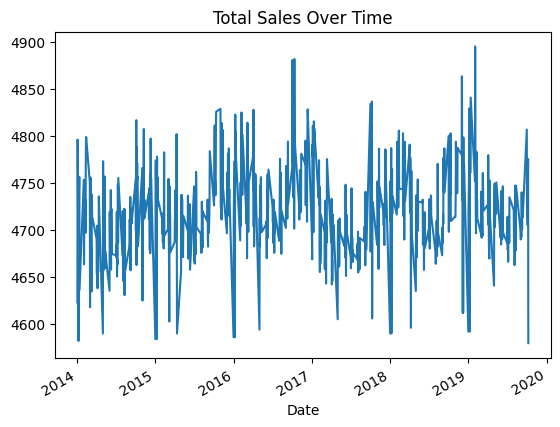

In [69]:
plt.figure()
df.groupby('Date')['Sales'].sum().plot()
plt.title("Total Sales Over Time")
plt.show()

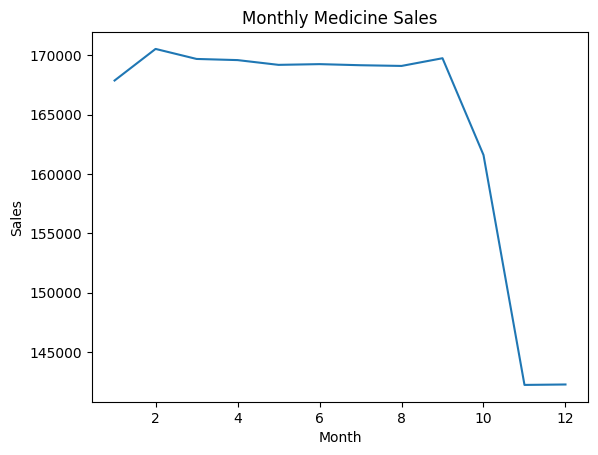

In [58]:
monthly_sales = df.groupby('month')['Sales'].sum()
plt.figure()
monthly_sales.plot()
plt.title("Monthly Medicine Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

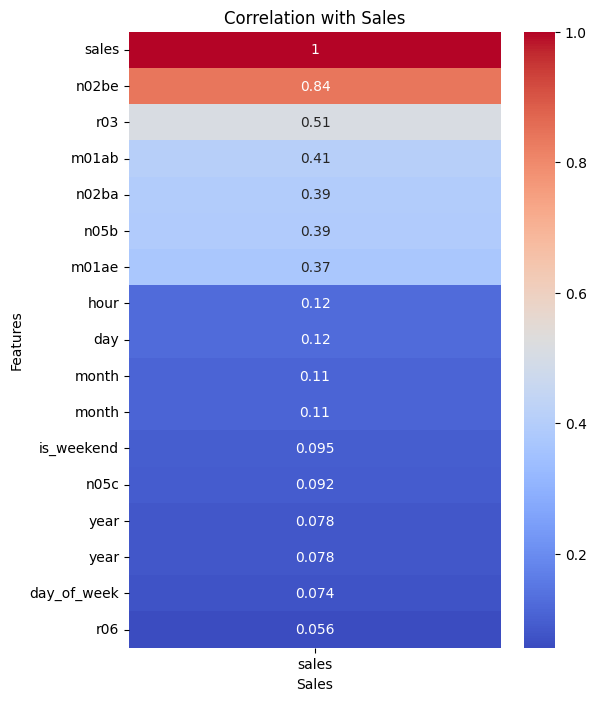

In [81]:
df.columns = df.columns.str.lower()
corr_with_sales = df.corr(numeric_only=True)['sales'].sort_values(ascending=False)
plt.figure(figsize=(6,8))
sns.heatmap(corr_with_sales.to_frame(), annot=True, cmap='coolwarm')

plt.title("Correlation with Sales")
plt.xlabel("Sales")
plt.ylabel("Features")

plt.show()

## Preparing data for modeling

The input features and target variable are defined, and the data is split into training and testing sets.

In [60]:
df.columns = df.columns.str.strip()
df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['year'] = df['Date'].dt.year
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df = df.dropna()

## Defining Features and Target

The independent variables (features) and dependent variable (Sales) are selected for model training.

In [72]:
X = df[['month', 'day', 'year', 'day_of_week', 'is_weekend']]
y = df['Sales']

## Splitting the Dataset

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

A Random Forest Regressor is used to train the model. It is effective for capturing complex relationships in the data.

In [63]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

The performance of the model is evaluated using the R² score, which indicates how well the model explains the variance in the data.

In [76]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.33132141604974896
Mean Absolute Error: 14.185692714520698


## Feature Importance

Feature importance helps identify which factors have the most influence on medicine demand prediction.

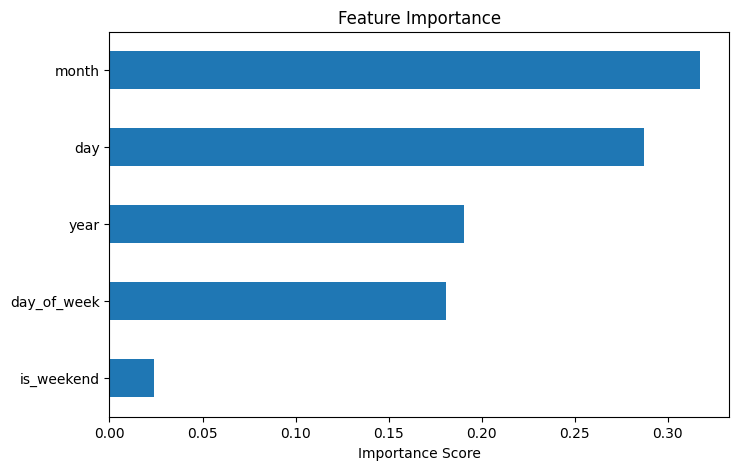

In [77]:
plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()